This notebook will plot maps of MODIS reflectance and model total water path to facilitate qualitative comparisons of the timing and spatial patterns of the event.

In [1]:
import pandas as pd
import xarray as xr
import datetime as dt
import numpy as np
import utils
import wrfpp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
import cartopy.crs as ccrs
from glob import glob
import seaborn as sns
import string

Fontconfig error: Cannot load default config file: No such file: (null)


# Read model output

In [2]:
lwp = xr.open_dataset(f"/mnt/data/model_output/thompson_derived_variables/lwp_2020-04-13_2020-04-17.nc")
lwp = lwp.assign_coords({
    "day": ("Time",[T.dt.day for T in lwp.Time]),
    "longitude": (["south_north","west_east"],lwp.XLONG.isel(Time=0).values),
    "latitude": (["south_north","west_east"],lwp.XLAT.isel(Time=0).values),
})
lwp = lwp.groupby(lwp.Time.dt.day).mean()

iwp = xr.open_dataset(f"/mnt/data/model_output/thompson_derived_variables/iwp_2020-04-13_2020-04-17.nc")
iwp = iwp.assign_coords({
    "day": ("Time",[T.dt.day for T in iwp.Time]),
    "longitude": (["south_north","west_east"],iwp.XLONG.isel(Time=0).values),
    "latitude": (["south_north","west_east"],iwp.XLAT.isel(Time=0).values),
})
iwp = iwp.groupby(iwp.Time.dt.day).mean()

rwp = xr.open_dataset(f"/mnt/data/model_output/thompson_derived_variables/rwp_2020-04-13_2020-04-17.nc")
rwp = rwp.assign_coords({
    "day": ("Time",[T.dt.day for T in rwp.Time]),
    "longitude": (["south_north","west_east"],rwp.XLONG.isel(Time=0).values),
    "latitude": (["south_north","west_east"],rwp.XLAT.isel(Time=0).values),
})
rwp = rwp.groupby(rwp.Time.dt.day).mean()

twp = lwp["cloud liquid water path"] + iwp["Cloud ice water path"]


In [3]:
seaice = xr.open_dataset(f"/mnt/data/model_output/ACI_OPT_2/SEAICE_2020-04-13_2020-04-17.nc").set_index(Time="XTIME")
seaice = seaice.assign_coords({
    "day": ("Time",[T.dt.day for T in seaice.Time]),
    "longitude": (["south_north","west_east"],seaice.XLONG.isel(Time=0).values),
    "latitude": (["south_north","west_east"],seaice.XLAT.isel(Time=0).values),
})
landmask = xr.open_dataarray("/mnt/data/model_output/ACI_OPT_2/LANDMASK.nc").set_index(Time="XTIME")
land = (landmask).where(~(seaice>0))
ocean = (land!=1)

seaice_daily = seaice.where(ocean).groupby(seaice.Time.dt.day).mean()

# Plot

In [4]:
mosaic = xr.open_dataset("/mnt/data/mosaic/nav/mosaic_coords_2020-04.nc")
mosaic = mosaic.assign_coords({"day": ("time", [T.dt.day for T in mosaic.time])})
mosaic = mosaic.groupby(mosaic.day).mean()
mosaic = mosaic.sel(day=seaice.day.values)


In [5]:
## Make a semi-transparent colour map to plot clouds over coloured background

# Pick a base colormap
base_cmap = matplotlib.cm.get_cmap("Greys_r")  # or "pink_r"

# Convert to array of RGBA values
cmap_array = base_cmap(np.linspace(0, 1, 256))

# Modify the alpha channel: make low values transparent
# cmap_array[:, -1] = np.linspace(0, 1, 256)  # alpha ramps from 0→1
# If you want "near-zero" only transparent (not the entire low end),
# you can instead threshold:
cmap_array[:,:-1] = 1
cmap_array[:, -1] = np.linspace(0, 1, 256)  # alpha ramps from 0→1
# cmap_array[:100, -1] = 0  # first 50 levels fully transparent
# cmap_array[100:, -1] = np.linspace(0, 1, 156)

# Create new colormap
transparent_cmap = ListedColormap(cmap_array)

/tmp/ipykernel_1386/4097482872.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = matplotlib.cm.get_cmap("Greys_r")  # or "pink_r"


2020-04-14


/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:862: FutureWarning: The behavior of this method will change in future versions. Use specific 'len(elem)' or 'elem is not None' test instead.
  if current and current.text == 'true':
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "1" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "2" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "3" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "4" already exists


2020-04-15


/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:862: FutureWarning: The behavior of this method will change in future versions. Use specific 'len(elem)' or 'elem is not None' test instead.
  if current and current.text == 'true':
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "1" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "2" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "3" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "4" already exists


2020-04-16


/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:862: FutureWarning: The behavior of this method will change in future versions. Use specific 'len(elem)' or 'elem is not None' test instead.
  if current and current.text == 'true':
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "1" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "2" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "3" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "4" already exists


2020-04-17


/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:862: FutureWarning: The behavior of this method will change in future versions. Use specific 'len(elem)' or 'elem is not None' test instead.
  if current and current.text == 'true':
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "1" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "2" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "3" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "4" already exists


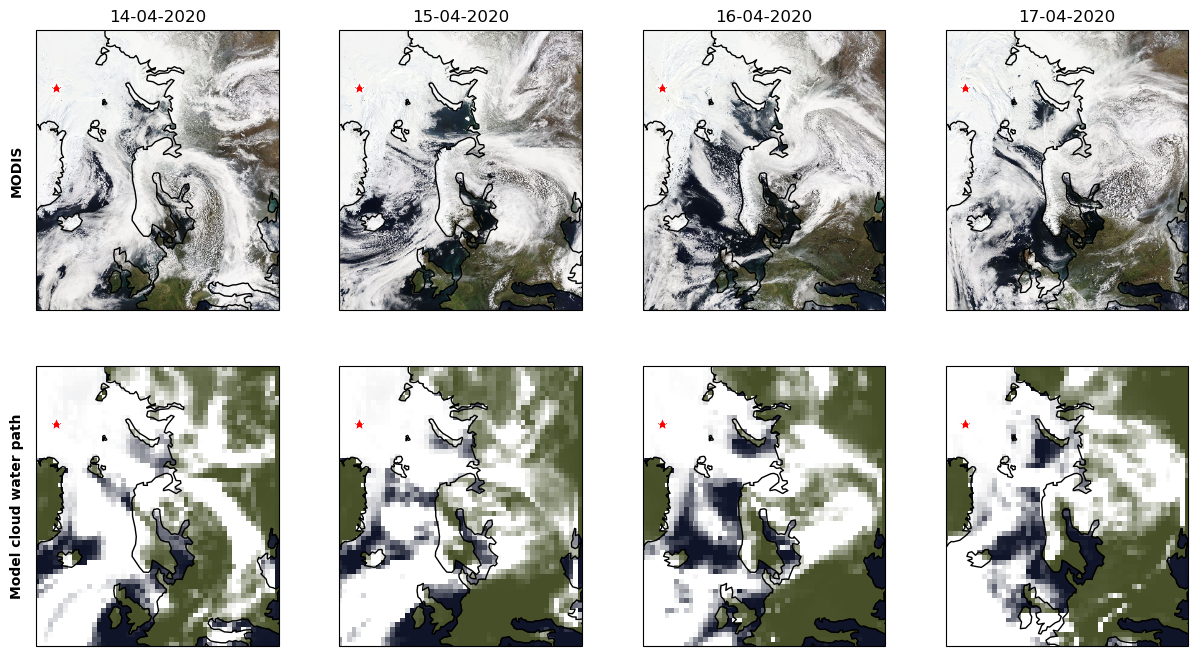

In [10]:
days = [14,15,16,17]


# make figure
fig, axes = plt.subplots(
    2, len(days),
    figsize=(15,8),
    subplot_kw=dict(projection=ccrs.NorthPolarStereo(central_longitude=-25))
)

# define land and ocean colours that somewhat resemble MODIS
land = cfeature.NaturalEarthFeature(
    'physical', 'land', '110m',
    edgecolor='k',
)
land_c = '#464F27'
ocean = cfeature.NaturalEarthFeature(
    "physical", "ocean", "110m"
)
ocean_c = "#0F1428"


for n in range(len(days)):
    # make axes
    col = axes[:,n]
    d = days[n]
    for ax in col:
        ax.coastlines(zorder=4)
        ax.set_extent([-30,80,50,90], crs=ccrs.PlateCarree())
        ax.spines['geo'].set_zorder(5)
        # add location of mosaic
        ax.plot(
            mosaic.isel(day=d).Longitude,
            mosaic.isel(day=d).Latitude,
            marker="*",
            mec="white",
            mfc="red",
            ms=10,
            zorder=5
        )
    col[1].add_feature(land, facecolor=land_c, zorder=1)
    col[1].add_feature(ocean, facecolor=ocean_c, zorder=1)

    # retrieve satellite data (code from Erin Raif)
    dateiso = f'2020-04-{d:02d}'
    print(dateiso)
    product = 'MODIS_Aqua_CorrectedReflectance_TrueColor'
    wmt_url = 'https://gibs.earthdata.nasa.gov/wmts/epsg4326/best/wmts.cgi'
    col[0].add_wmts(wmt_url, product, wmts_kwargs={'time': dateiso})

    # plot total cloud water path and sea ice in white
    twp_day = twp.sel(day=d)
    sic_day = seaice_daily.sel(day=d)
    clouds = col[1].pcolormesh(
        twp_day.longitude,
        twp_day.latitude,
        1000*twp_day.sel(pollution_state="polluted"),
        transform=ccrs.PlateCarree(),
        cmap=transparent_cmap,
        vmin=0, vmax=75,
        zorder=3
    )
    map = col[1].pcolormesh(
        sic_day.longitude,
        sic_day.latitude,
        100*sic_day.SEAICE.where(sic_day.SEAICE>0.15),
        cmap=transparent_cmap,
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    col[0].set_title(f"{d}-04-2020")

# labels
axes[0,0].text(
    s="MODIS",
    x=-0.05, y=0.5,
    ha="right", va="center",
    multialignment="center",
    transform=axes[0,0].transAxes,
    weight="bold",
    rotation=90,
)
axes[1,0].text(
    s="Model cloud water path",
    x=-0.05, y=0.5,
    ha="right", va="center",
    multialignment="center",
    transform=axes[1,0].transAxes,
    weight="bold",
    rotation=90,
)

plt.savefig("../figures/modis_wrfchem_cloud_daily_maps.png", bbox_inches="tight")
